# Fuzzy Regression Discontinuity Design


**🌐 Language:** **English** | [한국어 →](/fuzzy-rdd-ko)

<small><em>Written by Jiwoo Son · <a href="https://github.com/bungaedm">GitHub</a> · <a href="https://www.linkedin.com/in/jiwoo-son-3207021a7/">LinkedIn</a></em></small>


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings

plt.rcParams['axes.unicode_minus'] = False

np.random.seed(2026)
warnings.filterwarnings('ignore')

## Recap. Sharp vs Fuzzy RDD

In the previous chapter, we covered Sharp RDD. In Sharp RDD, the cutoff $c$ **completely** determines treatment assignment.

$$D_i^{\text{Sharp}} = \mathbf{1}[X_i \geq c]$$

Using an exam score cutoff of 70, anyone scoring 70 or above must receive the scholarship, and anyone below can never receive it.

In reality, however, such "perfect rules" are rare. Even above 70, a student might miss the application deadline, be disqualified for missing documents, or simply not apply because their family is wealthy. Conversely, someone scoring 69 might receive it through a re-review. When the cutoff creates a **discontinuous jump** in the probability of treatment but does not fully determine it, we call this **Fuzzy RDD**.

$$\lim_{x \rightarrow c+} \Pr(D_i = 1 \mid X_i = x) \;\neq\; \lim_{x \rightarrow c-} \Pr(D_i = 1 \mid X_i = x)$$

| | Treatment Assignment | Change at Cutoff | Estimation Method |
|------|-------------|--------------|------|
| **Sharp RDD** | $D_i = \mathbf{1}[X_i \geq c]$ | Treatment probability 0 → 1 | OLS (discontinuous regression) |
| **Fuzzy RDD** | $\Pr(D_i=1)$ is discontinuous at $c$ | Partial jump (e.g., 15% → 65%) | 2SLS (IV) |

In [31]:
def plot_rdd_type():
    c = 0
    R = np.linspace(-3, 3, 300)
    
    D_sharp = np.where(R >= c, 1.0, 0.0)
    
    D_fuzzy = np.where(R >= c,
                       0.65 + 0.1 * np.tanh(R * 2),
                       0.15 + 0.1 * np.tanh(R * 2))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # ── Sharp RDD ──
    ax = axes[0]
    ax.plot(R[R <  c], D_sharp[R <  c], 'tomato',    linewidth=3, label=r'$P(D=1|R)$: $R < c$')
    ax.plot(R[R >= c], D_sharp[R >= c], 'steelblue', linewidth=3, label=r'$P(D=1|R)$: $R \geq c$')
    ax.axvline(c, color='gray', linestyle=':', linewidth=1.5)
    ax.scatter([c], [0], s=80, color='tomato', zorder=5, edgecolors='tomato', facecolors='none', linewidths=2)
    ax.scatter([c], [1], s=80, zorder=5)
    ax.annotate('', xy=(c, 1.0), xytext=(c, 0.0),
                arrowprops=dict(arrowstyle='<->', color='black', lw=2))
    ax.text(c + 0.1, 0.5, '0 → 1\n(perfect jump)', fontsize=11, va='center', fontweight='bold')
    ax.text(c + 0.05, -0.07, '$c$', fontsize=12, color='gray')
    ax.set_ylim(-0.15, 1.25)
    ax.set_title('Sharp RDD', fontsize=13, fontweight='bold')
    ax.set_xlabel('Running Variable $R$', fontsize=11)
    ax.set_ylabel(r'$P(D=1 \mid R)$', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # ── Fuzzy RDD ──
    ax = axes[1]
    ax.plot(R[R <  c], D_fuzzy[R <  c], 'tomato',    linewidth=3, label=r'$P(D=1|R)$: $R < c$')
    ax.plot(R[R >= c], D_fuzzy[R >= c], 'steelblue', linewidth=3, label=r'$P(D=1|R)$: $R \geq c$')
    ax.axvline(c, color='gray', linestyle=':', linewidth=1.5)
    
    d_l = np.interp(c - 0.009, R, D_fuzzy)
    d_r = np.interp(c + 0.009, R, D_fuzzy)
    ax.scatter([c], [d_l], s=80, color='tomato', zorder=5, facecolors='none', edgecolors='tomato', linewidths=2)
    ax.scatter([c], [d_r], s=80, zorder=5)
    ax.annotate('', xy=(c, d_r), xytext=(c, d_l),
                arrowprops=dict(arrowstyle='<->', color='black', lw=2))
    ax.text(c + 0.1, (d_l + d_r) / 2,
            f'{d_l:.2f} → {d_r:.2f}\n(partial jump)', fontsize=11, va='center', fontweight='bold')
    ax.text(c + 0.05, -0.07, '$c$', fontsize=12, color='gray')
    ax.set_ylim(-0.15, 1.25)
    ax.set_title('Fuzzy RDD', fontsize=13, fontweight='bold')
    ax.set_xlabel('Running Variable $R$', fontsize=11)
    ax.set_ylabel(r'$P(D=1 \mid R)$', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    fig.suptitle(r'Sharp vs Fuzzy RDD — $P(D=1 \mid R)$', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

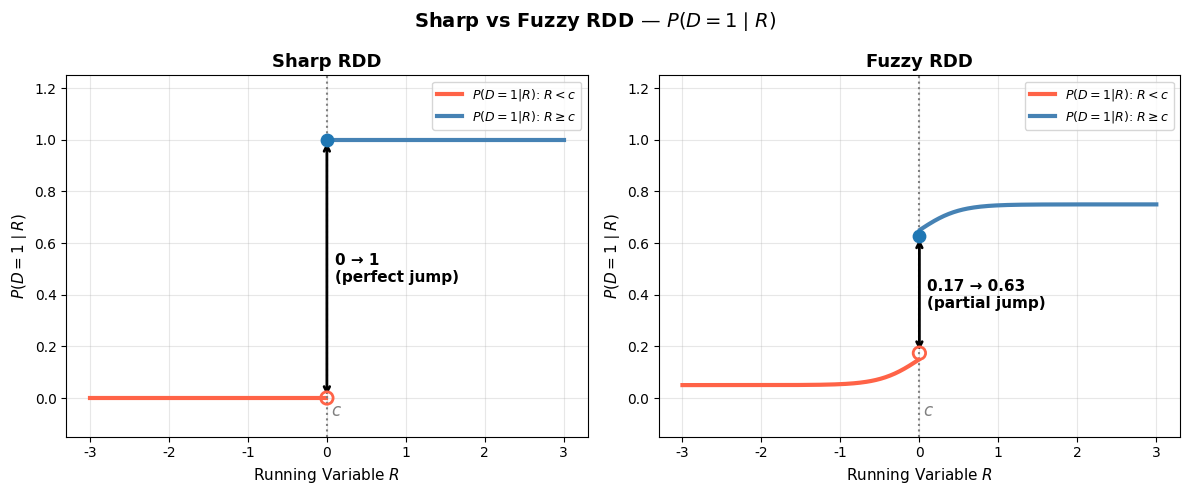

In [32]:
plot_rdd_type()

## 1. What is Fuzzy RDD?

In one sentence, Fuzzy RDD is RDD for situations where the cutoff does not "force" treatment.

For example, suppose a student becomes eligible to **apply** for a scholarship if they score 70 on the exam. Under Sharp RDD, everyone who becomes eligible would receive the scholarship. But in reality:

- A student who scored 71 and became eligible but missed the application window
- A student who scored 72 but was disqualified for incomplete documents
- A student who scored 75 but did not apply because their family is wealthy

Conversely, someone scoring 68 might still receive it through a special review or appeals process.

The cutoff determines **eligibility**, but actual treatment does not necessarily follow from that eligibility. This is the world of Fuzzy RDD.

In this situation, we must distinguish the key variables:

- $X_i$: Exam score (Running variable)
- $Z_i = \mathbf{1}[X_i \geq 70]$: Scholarship **eligibility** (Instrumental variable)
- $D_i$: Actual scholarship **receipt** (Treatment variable)
- $Y_i$: GPA (Outcome variable)

In Sharp RDD, $Z_i = D_i$. In Fuzzy RDD, $Z_i \neq D_i$. $Z_i$ influences $D_i$ but does not fully determine it.

## 2. Estimation Target

Fuzzy RDD estimates the LATE restricted to **Compliers**.

Based on the value of the instrumental variable $Z_i$ (eligibility), individuals can be classified into four types.

In [33]:
pd.DataFrame({
    'Type': ['Complier', 'Always-taker', 'Never-taker', 'Defier'],
    'D when Z=0': [0, 1, 0, 1],
    'D when Z=1': [1, 1, 0, 0],
    'Description': [
        'Takes treatment only when eligible \u2190 estimation target',
        'Always takes treatment regardless of eligibility',
        'Never takes treatment even when eligible',
        'Refuses treatment when eligible (excluded by monotonicity assumption)',
    ]
})

,Type,D when Z=0,D when Z=1,Description
0,Complier,0,1,Takes treatment only when eligible ← estimatio...
1,Always-taker,1,1,Always takes treatment regardless of eligibility
2,Never-taker,0,0,Never takes treatment even when eligible
3,Defier,1,0,Refuses treatment when eligible (excluded by m...


Under the Monotonicity assumption, we assume there are no Defiers. The effect estimated near the cutoff is then:

$$\tau_{Fuzzy} = \mathbb{E}[Y_i(1) - Y_i(0) \mid \text{Complier},\; X_i = c]$$

That is, this is the treatment effect — near the cutoff — for those who received treatment because they became eligible (Compliers).

**Difference from ATE (Average Treatment Effect)**: Always-takers and Never-takers are not included. We cannot estimate the effect for those who always receive (or never receive) treatment regardless of eligibility. This is both a fundamental limitation of Fuzzy RDD and, at the same time, an honest estimate.

## 3. Key Assumptions (IV)

Fuzzy RDD is fundamentally an **Instrumental Variable (IV)** estimation problem.

We use $Z_i = \mathbf{1}[X_i \geq c]$ as the instrumental variable. For this instrument to be valid, three conditions must hold.

### Relevance

$Z_i$ must have a meaningful effect on $D_i$. Eligibility must raise the probability of treatment.

$$\text{Cov}(Z_i,\, D_i) \neq 0$$

This is verified using the F-statistic from the first-stage regression. Conventionally, $F > 10$ is considered a strong instrument.

### Exclusion Restriction

$Z_i$ must affect $Y_i$ only through $D_i$. That is, the mere fact of crossing the 70-point threshold should not directly change GPA. GPA should rise because the scholarship was received, not simply because eligibility was granted.

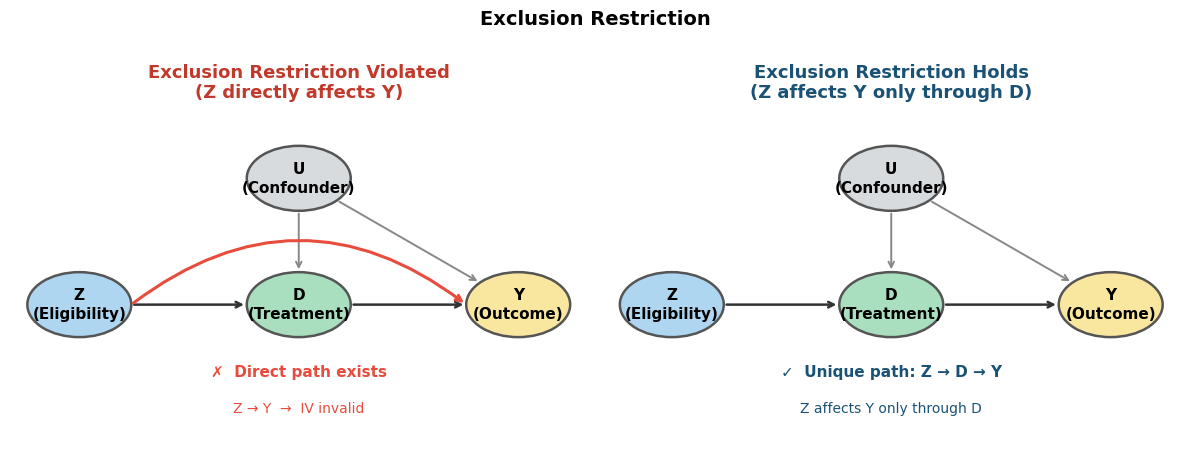

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

pos = {'Z': (0.12, 0.50), 'D': (0.50, 0.50), 'Y': (0.88, 0.50), 'U': (0.50, 0.85)}
node_colors = {'Z': '#AED6F1', 'D': '#A9DFBF', 'Y': '#F9E79F', 'U': '#D7DBDD'}
node_labels = {'Z': 'Z\n(Eligibility)', 'D': 'D\n(Treatment)', 'Y': 'Y\n(Outcome)', 'U': 'U\n(Confounder)'}
R = 0.09

def draw_nodes(ax):
    for name, (x, y) in pos.items():
        circle = plt.Circle((x, y), R, color=node_colors[name], ec='#555', lw=1.8, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, node_labels[name], ha='center', va='center', fontsize=11,
                fontweight='bold', zorder=4, linespacing=1.3)

def arrow(ax, a, b, color='#333', lw=1.8, rad=0.0, ls='-'):
    x1, y1 = pos[a]; x2, y2 = pos[b]
    dx, dy = x2 - x1, y2 - y1
    dist = (dx**2 + dy**2) ** 0.5
    sx = x1 + R * dx / dist;  sy = y1 + R * dy / dist
    ex = x2 - R * dx / dist;  ey = y2 - R * dy / dist
    style = f'arc3,rad={rad}' if rad != 0 else 'arc3,rad=0'
    ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                connectionstyle=style,
                                linestyle=ls))

# ── Left: Exclusion Restriction Violated ──
ax = axes[0]
ax.set_xlim(0, 1); ax.set_ylim(0.1, 1.05); ax.axis('off')
ax.set_title('Exclusion Restriction Violated\n(Z directly affects Y)', fontsize=13, fontweight='bold', color='#C0392B')
draw_nodes(ax)
arrow(ax, 'Z', 'D')
arrow(ax, 'D', 'Y')
arrow(ax, 'U', 'D', color='#888', lw=1.4)
arrow(ax, 'U', 'Y', color='#888', lw=1.4)
arrow(ax, 'Z', 'Y', color='#E74C3C', lw=2.2, rad=-0.38)   # direct path (violation)
# ✗ annotation
mx = (pos['Z'][0] + pos['Y'][0]) / 2
my = min(pos['Z'][1], pos['Y'][1]) - 0.20
ax.text(mx, my, '\u2717  Direct path exists', color='#E74C3C', fontsize=11,
        ha='center', fontweight='bold')
ax.text(mx, my - 0.10, 'Z \u2192 Y  \u2192  IV invalid', color='#E74C3C', fontsize=10, ha='center')

# ── Right: Exclusion Restriction Holds ──
ax2 = axes[1]
ax2.set_xlim(0, 1); ax2.set_ylim(0.1, 1.05); ax2.axis('off')
ax2.set_title('Exclusion Restriction Holds\n(Z affects Y only through D)', fontsize=13, fontweight='bold', color='#1A5276')
draw_nodes(ax2)
arrow(ax2, 'Z', 'D')
arrow(ax2, 'D', 'Y')
arrow(ax2, 'U', 'D', color='#888', lw=1.4)
arrow(ax2, 'U', 'Y', color='#888', lw=1.4)
mx2 = (pos['Z'][0] + pos['Y'][0]) / 2
my2 = min(pos['Z'][1], pos['Y'][1]) - 0.20
ax2.text(mx2, my2, '\u2713  Unique path: Z \u2192 D \u2192 Y', color='#1A5276',
         fontsize=11, ha='center', fontweight='bold')
ax2.text(mx2, my2 - 0.10, 'Z affects Y only through D', color='#1A5276',
         fontsize=10, ha='center')

plt.suptitle('Exclusion Restriction', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Monotonicity

There must be no Defiers. No one should refuse treatment when they become eligible.

$$D_i(Z=1) \geq D_i(Z=0) \quad \forall i$$

When these three assumptions hold, the Fuzzy LATE can be expressed cleanly as the **Wald estimator**:

$$\hat{\tau}_{Fuzzy} = \frac{\text{ITT}_Y}{\text{ITT}_D} = \frac{\text{Jump in Y}}{\text{Jump in D}}$$

$\text{ITT}_Y$ is the effect of eligibility on the outcome (Reduced form), and $\text{ITT}_D$ is the effect of eligibility on actual treatment (First stage). Intuitively, dividing "how much Y jumped" by "how much D jumped" gives the per-unit effect for the Compliers who actually received treatment.

## 4. Understanding Fuzzy RDD with Formulas

The ultimate goal of Fuzzy RDD is to obtain the LATE via the **Wald estimator**.

$$\hat{\tau}_{Fuzzy} = \frac{\widehat{\text{ITT}}_Y}{\widehat{\text{ITT}}_D} = \frac{\text{Jump in Y}}{\text{Jump in D}}$$

To do this, we must distinguish **three regressions**.

| Name | Path | Estimation Target | Role |
|------|------|-----------|------|
| **Reduced Form** | $Z_i \rightarrow Y_i$ | $\widehat{\text{ITT}}_Y$ | Wald numerator / pre-check |
| **2SLS First Stage** | $Z_i \rightarrow D_i$ | $\widehat{\text{ITT}}_D$ | Wald denominator / instrument strength |
| **2SLS Second Stage** | $\hat{D}_i \rightarrow Y_i$ | $\hat{\beta}_1 = \text{LATE}$ | Final estimate (= Wald equivalent) |

---

### Reduced Form: $Z_i \rightarrow Y_i$

$$Y_i = \gamma_0 + \gamma_1 Z_i + \gamma_2(X_i - c) + \gamma_3 Z_i(X_i - c) + \varepsilon_i$$

- **Purpose**
    - **Pre-check role**: Before running 2SLS, we first verify whether "the instrument $Z_i$ actually reaches the outcome $Y_i$." If $\hat{\gamma}_1 \approx 0$, running 2SLS will also yield a LATE estimate near zero, signaling that the analysis design itself needs to be reconsidered.
    - **Wald numerator role**: At the same time, $\hat{\gamma}_1$ is used directly as the Wald numerator ($\widehat{\text{ITT}}_Y$). Thus, the Reduced Form serves simultaneously as a pre-check and as an ingredient for the final estimate.
- **Key coefficient**: $\hat{\gamma}_1 = \widehat{\text{ITT}}_Y$ (jump in Y at the cutoff)

---

### 2SLS (Two-Stage Least Squares)

$D_i$ (actual treatment) is an **endogenous variable**. People who received the scholarship may have differed from those who did not from the start (in ability, motivation, etc.), so regressing $Y_i$ directly on $D_i$ produces bias.

2SLS extracts from $D_i$ only **the part exogenously driven by instrument $Z_i$**, and uses that part to explain $Y_i$.

#### First Stage: $Z_i \rightarrow D_i$

$$D_i = \alpha_0 + \alpha_1 Z_i + \alpha_2(X_i - c) + \alpha_3 Z_i(X_i - c) + \varepsilon_i^{(1)}$$

- **Purpose**: Confirms how much eligibility ($Z_i$) changes actual treatment ($D_i$).
- **Key coefficient**: $\hat{\alpha}_1 = \widehat{\text{ITT}}_D$ (jump in treatment probability at the cutoff)
- **Diagnostic**: F-statistic $\geq 10$ indicates a strong instrument; below 10 signals a weak instrument problem.
- **Output**: Fitted values $\hat{D}_i$ — the exogenous part of treatment explained by the instrument

#### Second Stage: $\hat{D}_i \rightarrow Y_i$

$$Y_i = \beta_0 + \beta_1 \hat{D}_i + \beta_2(X_i - c) + \beta_3 \hat{D}_i(X_i - c) + \varepsilon_i^{(2)}$$

- **Purpose**: By plugging the first-stage fitted values $\hat{D}_i$ in place of the treatment variable, we estimate the treatment effect with endogeneity removed.
- **Key coefficient**: $\hat{\beta}_1$ = **LATE estimator**

---

### Final Calculation: Wald Estimator

The $\hat{\beta}_1$ from the second stage of 2SLS is exactly equal to the Wald estimator.

$$\hat{\beta}_1 = \frac{\hat{\gamma}_1}{\hat{\alpha}_1} = \frac{\widehat{\text{ITT}}_Y}{\widehat{\text{ITT}}_D}$$

For example, if GPA increases by 0.3 points when eligibility is granted ($\text{ITT}_Y$) and the treatment probability increases by 50 percentage points ($\text{ITT}_D$), then the per-Complier effect is $0.3 \div 0.5 = 0.6$ points.

> **Note**: Implementing the second stage manually yields the correct point estimate ($\hat{\beta}_1$), but **standard errors are underestimated**. In practice, an IV estimation package such as `linearmodels` should be used.

## 5. Visualization

We visualize the three stages of Fuzzy RDD estimation on one screen. Before looking at the graphs, make sure you understand what each panel contains.

- **Left — Reduced Form (Z → Y)**: A scatter plot of exam score (X) and GPA (Y). Regression lines are fitted on each side of the cutoff, showing how much GPA jumps at the cutoff ($\widehat{\text{ITT}}_Y$). This serves as a pre-check to confirm that the instrument actually reaches the outcome before running 2SLS.
- **Center — 2SLS First Stage (Z → D)**: A scatter plot of exam score (X) and actual treatment status (D). This shows how much treatment probability jumps at the cutoff ($\widehat{\text{ITT}}_D$) and visually confirms the strength of the instrument.
- **Right — 2SLS Second Stage Result**: The LATE estimated by 2SLS and its 95% confidence interval. The diamond (◆) is the point estimate, the horizontal line is the confidence interval, and the green dashed line is the True LATE set in the simulation.

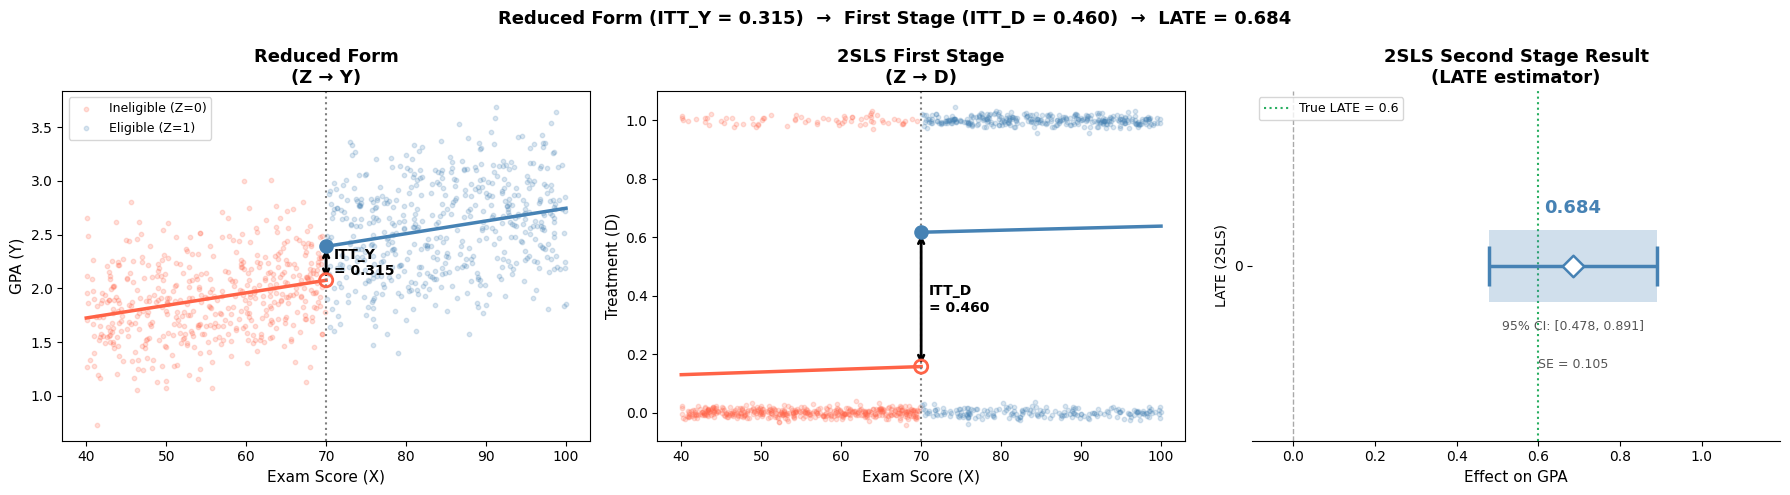

In [35]:
n = 1000
cutoff = 70
true_late = 0.6

score   = np.random.uniform(40, 100, n)
elig    = (score >= cutoff).astype(int)
treated = np.where(elig == 1,
                   np.random.binomial(1, 0.65, n),
                   np.random.binomial(1, 0.15, n))
gpa = (2.0 + 0.012*(score - cutoff)
       + true_late * treated
       + np.random.normal(0, 0.3, n))

df_viz = pd.DataFrame({'score': score, 'elig': elig,
                       'treated': treated, 'gpa': gpa,
                       'score_c': score - cutoff})

# First stage → D_hat
fs_viz = smf.ols('treated ~ elig + score_c + elig:score_c', data=df_viz).fit()
df_viz['D_hat'] = fs_viz.fittedvalues

# Second stage → LATE
ss_viz  = smf.ols('gpa ~ D_hat + score_c + D_hat:score_c', data=df_viz).fit()
LATE    = ss_viz.params['D_hat']
LATE_se = ss_viz.bse['D_hat']
LATE_ci = ss_viz.conf_int().loc['D_hat'].values   # [lower, upper]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
left  = df_viz[df_viz['elig'] == 0]
right = df_viz[df_viz['elig'] == 1]
xs_l  = np.linspace(40, cutoff, 100)
xs_r  = np.linspace(cutoff, 100, 100)

ACCENT = 'steelblue'
GREEN  = '#27ae60'
GRAY   = '#555555'

# ── Left: Reduced Form (Z → Y) ──
ax = axes[0]
ax.scatter(left['score'],  left['gpa'],  color='tomato',    alpha=0.2, s=10, label='Ineligible (Z=0)')
ax.scatter(right['score'], right['gpa'], color='steelblue', alpha=0.2, s=10, label='Eligible (Z=1)')
m_y_l = smf.ols('gpa ~ score_c', data=left).fit()
m_y_r = smf.ols('gpa ~ score_c', data=right).fit()
ax.plot(xs_l, m_y_l.predict(pd.DataFrame({'score_c': xs_l - cutoff})), color='tomato',    lw=2.5)
ax.plot(xs_r, m_y_r.predict(pd.DataFrame({'score_c': xs_r - cutoff})), color='steelblue', lw=2.5)
y_l_gpa = m_y_l.params['Intercept']
y_r_gpa = m_y_r.params['Intercept']
ax.scatter([cutoff], [y_l_gpa], s=90, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax.scatter([cutoff], [y_r_gpa], s=90, color='steelblue', zorder=6)
ax.annotate('', xy=(cutoff, y_r_gpa), xytext=(cutoff, y_l_gpa),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.text(cutoff + 1, (y_l_gpa + y_r_gpa) / 2,
        f'ITT_Y\n= {y_r_gpa - y_l_gpa:.3f}', fontsize=10, fontweight='bold', va='center')
ax.axvline(cutoff, color='gray', ls=':', lw=1.5)
ax.set_title('Reduced Form\n(Z \u2192 Y)', fontsize=13, fontweight='bold')
ax.set_xlabel('Exam Score (X)', fontsize=11)
ax.set_ylabel('GPA (Y)', fontsize=11)
ax.legend(fontsize=9)

# ── Center: 2SLS First Stage (Z → D) ──
ax2 = axes[1]
ax2.scatter(left['score'],  left['treated']  + np.random.normal(0, 0.012, len(left)),
            color='tomato',    alpha=0.2, s=10)
ax2.scatter(right['score'], right['treated'] + np.random.normal(0, 0.012, len(right)),
            color='steelblue', alpha=0.2, s=10)
m_d_l = smf.ols('treated ~ score_c', data=left).fit()
m_d_r = smf.ols('treated ~ score_c', data=right).fit()
ax2.plot(xs_l, m_d_l.predict(pd.DataFrame({'score_c': xs_l - cutoff})), color='tomato',    lw=2.5)
ax2.plot(xs_r, m_d_r.predict(pd.DataFrame({'score_c': xs_r - cutoff})), color='steelblue', lw=2.5)
y_l_d = m_d_l.params['Intercept']
y_r_d = m_d_r.params['Intercept']
ax2.scatter([cutoff], [y_l_d], s=90, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax2.scatter([cutoff], [y_r_d], s=90, color='steelblue', zorder=6)
ax2.annotate('', xy=(cutoff, y_r_d), xytext=(cutoff, y_l_d),
             arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax2.text(cutoff + 1, (y_l_d + y_r_d) / 2,
         f'ITT_D\n= {y_r_d - y_l_d:.3f}', fontsize=10, fontweight='bold', va='center')
ax2.axvline(cutoff, color='gray', ls=':', lw=1.5)
ax2.set_title('2SLS First Stage\n(Z \u2192 D)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Exam Score (X)', fontsize=11)
ax2.set_ylabel('Treatment (D)', fontsize=11)

# ── Right: Forest Plot (LATE + 95% CI) ──
ax3 = axes[2]
y_pos = 0
ax3.barh(y_pos, LATE_ci[1] - LATE_ci[0], left=LATE_ci[0],
         height=0.25, color=ACCENT, alpha=0.25, zorder=2) # CI shading
ax3.hlines(y_pos, LATE_ci[0], LATE_ci[1],
           colors=ACCENT, lw=2.5, zorder=3) # CI horizontal line
ax3.vlines([LATE_ci[0], LATE_ci[1]], y_pos - 0.07, y_pos + 0.07,
           colors=ACCENT, lw=2.5, zorder=3) # end caps
ax3.scatter([LATE], [y_pos], color='white', s=120,
            marker='D', zorder=5, edgecolors=ACCENT, linewidths=1.8) # point estimate (diamond)
ax3.axvline(true_late, color=GREEN, lw=1.5, ls=':',
            label=f'True LATE = {true_late}', zorder=1) # True effect vertical line
ax3.axvline(0, color=GRAY, lw=1, ls='--', alpha=0.5, zorder=1) # zero reference line
ax3.text(LATE, y_pos + 0.18, f'{LATE:.3f}',
         ha='center', color=ACCENT, fontsize=13, fontweight='bold')
ax3.text(LATE, y_pos - 0.22,
         f'95% CI: [{LATE_ci[0]:.3f}, {LATE_ci[1]:.3f}]',
         ha='center', color=GRAY, fontsize=9)
ax3.text(LATE, y_pos - 0.35, f'SE = {LATE_se:.3f}',
         ha='center', color=GRAY, fontsize=9)

ax3.set_xlim(min(LATE_ci[0] - 0.3, -0.1), max(LATE_ci[1] + 0.3, true_late + 0.2))
ax3.set_ylim(-0.6, 0.6)
ax3.set_yticks([0])
ax3.set_title('2SLS Second Stage Result\n(LATE estimator)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Effect on GPA', fontsize=11)
ax3.set_ylabel('LATE (2SLS)', fontsize=10)
ax3.legend(fontsize=9, loc='upper left')
ax3.spines[['top', 'right', 'left']].set_visible(False)

plt.suptitle(
    f'Reduced Form (ITT_Y = {y_r_gpa - y_l_gpa:.3f})  \u2192  '
    f'First Stage (ITT_D = {y_r_d - y_l_d:.3f})  \u2192  '
    f'LATE = {LATE:.3f}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

Here are the key points to check when reading the graphs.

**Left and center: Compare the size of the jumps.** The Y jump in the Reduced Form ($\widehat{\text{ITT}}_Y$) should be smaller than the D jump in the First Stage ($\widehat{\text{ITT}}_D$) in the center panel. In Fuzzy RDD, only a fraction of those who become eligible actually receive treatment. If the Y jump is larger than the D jump, that is a signal of a problem with the design or the data.

**Right: Check whether the confidence interval includes zero.** If the confidence interval includes zero, we fail to reject the hypothesis that "there is no treatment effect." Also check how close the True LATE (green dashed line) is to the estimate (◆). The larger the sample, the closer the estimate converges to the True LATE.

**Verify by computing the Wald estimator directly.** Dividing $\widehat{\text{ITT}}_Y$ from the left graph by $\widehat{\text{ITT}}_D$ from the center graph yields the same value as the LATE in the Forest Plot. This relationship is also summarized in the overall title.

## 6. Examples

### Example 1: Scholarship Eligibility

| Item | Content |
|------|------|
| **Running Variable** | Exam score |
| **Cutoff** | 70 points |
| **Z (Eligibility)** | Score ≥ 70 → eligible to apply for scholarship |
| **D (Treatment)** | Actual scholarship receipt |
| **Y (Outcome)** | GPA |

Crossing 70 points grants application eligibility, but students may not apply or may be disqualified for missing documents. Conversely, some may receive the scholarship through a special review even below the cutoff. Since D does not fully follow Z, this is a Fuzzy design.

Wald estimator example:

| | Below cutoff (Z=0) | Above cutoff (Z=1) |
|---|---|---|
| Actual receipt rate (ITT_D) | 10% | 65% |
| Average GPA (ITT_Y) | 2.0 | 2.3 |

$$\hat{\tau}_{Fuzzy} = \frac{2.3 - 2.0}{0.65 - 0.10} = \frac{0.3}{0.55} \approx 0.55$$

→ The effect on GPA for students who received the scholarship because they became eligible (Compliers) is approximately 0.55 points.

---

### Example 2: Health Insurance Eligibility (Medicare at 65)

| Item | Content |
|------|------|
| **Running Variable** | Age |
| **Cutoff** | Age 65 |
| **Z (Eligibility)** | Age ≥ 65 → eligible to enroll in Medicare |
| **D (Treatment)** | Actual Medicare enrollment |
| **Y (Outcome)** | Healthcare utilization, mortality, etc. |

Turning 65 grants Medicare eligibility, but not everyone enrolls immediately. Those with employer-sponsored insurance or low-income individuals already on Medicaid may delay enrollment. Card et al. (2008) used this design to estimate the causal effect of Medicare enrollment on healthcare utilization and mortality.

In this way, Fuzzy RDD naturally arises whenever "eligibility" and "actual receipt" are separated.

## 7. Simulation Code

Let us run a simulation directly. We set up a scenario where scholarship application eligibility is granted at an exam score of 70, with a **compliance rate** of 50%.

- Treatment rate among the ineligible group: 10% (Always-takers)
- Treatment rate among the eligible group: 60% (Always-takers + Compliers)
- Complier proportion: 60% - 10% = 50%
- True treatment effect (True LATE): GPA +0.5 points

In [36]:
np.random.seed(2026)
n = 1000
cutoff = 70
true_late = 0.5
p_below = 0.10   # always-taker proportion
p_above = 0.60   # always-taker + complier proportion

score   = np.random.uniform(40, 100, n)
elig    = (score >= cutoff).astype(int)            # Z_i
treated = np.where(elig == 1,
                   np.random.binomial(1, p_above, n),
                   np.random.binomial(1, p_below, n))  # D_i
gpa = (2.0
       + 0.012 * (score - cutoff)   # natural effect of running variable
       + true_late * treated         # treatment effect (only for Compliers)
       + np.random.normal(0, 0.3, n))

df = pd.DataFrame({
    'score': score, 'elig': elig,
    'treated': treated, 'gpa': gpa,
    'score_c': score - cutoff,
})

print(f"Total sample: {n}")
print(f"Ineligible (Z=0) - treatment rate: {treated[elig==0].mean():.1%}")
print(f"Eligible (Z=1) - treatment rate: {treated[elig==1].mean():.1%}")
print(f"Treatment probability jump (estimated compliance rate): {treated[elig==1].mean() - treated[elig==0].mean():.1%}")
df.head(8)

Total sample: 1000
Ineligible (Z=0) - treatment rate: 11.1%
Eligible (Z=1) - treatment rate: 56.9%
Treatment probability jump (estimated compliance rate): 45.8%


,score,elig,treated,gpa,score_c
0,53.160738,0,0,1.606919,-16.839262
1,64.780704,0,0,2.420633,-5.219296
2,98.598129,1,0,2.733795,28.598129
3,45.333941,0,0,1.691864,-24.666059
4,68.757392,0,0,1.821720,-1.242608
5,99.253030,1,0,2.183469,29.253030
6,51.888465,0,0,1.491415,-18.111535
7,94.702911,1,0,2.066975,24.702911


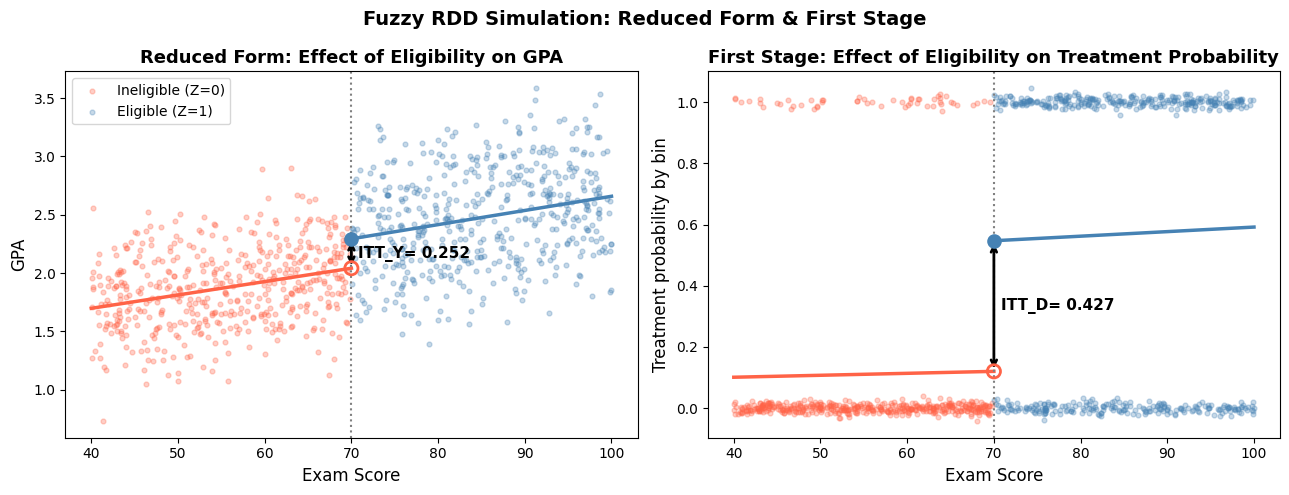

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: GPA scatter plot (Reduced form) ──
ax = axes[0]
left_  = df[df['elig'] == 0]
right_ = df[df['elig'] == 1]
ax.scatter(left_['score'],  left_['gpa'],  color='tomato',    alpha=0.3, s=12, label='Ineligible (Z=0)')
ax.scatter(right_['score'], right_['gpa'], color='steelblue', alpha=0.3, s=12, label='Eligible (Z=1)')

m_y_l = smf.ols('gpa ~ score_c', data=left_).fit()
m_y_r = smf.ols('gpa ~ score_c', data=right_).fit()
xs_l = np.linspace(40, cutoff, 100)
xs_r = np.linspace(cutoff, 100, 100)
ax.plot(xs_l, m_y_l.predict(pd.DataFrame({'score_c': xs_l - cutoff})), color='tomato',    lw=2.5)
ax.plot(xs_r, m_y_r.predict(pd.DataFrame({'score_c': xs_r - cutoff})), color='steelblue', lw=2.5)
y_l_gpa = m_y_l.params['Intercept']
y_r_gpa = m_y_r.params['Intercept']
ax.scatter([cutoff], [y_l_gpa], s=90, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax.scatter([cutoff], [y_r_gpa], s=90, color='steelblue', zorder=6)
ax.annotate('', xy=(cutoff, y_r_gpa), xytext=(cutoff, y_l_gpa),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.text(cutoff + 0.8, (y_l_gpa + y_r_gpa)/2,
        f'ITT_Y= {y_r_gpa - y_l_gpa:.3f}', fontsize=11, fontweight='bold', va='center')
ax.axvline(cutoff, color='gray', ls=':', lw=1.5)
ax.set_title('Reduced Form: Effect of Eligibility on GPA', fontsize=13, fontweight='bold')
ax.set_xlabel('Exam Score', fontsize=12); ax.set_ylabel('GPA', fontsize=12)
ax.legend(fontsize=10)

# ── Right: Treatment probability (First stage) ──
ax2 = axes[1]
ax2.scatter(left_['score'],  left_['treated']  + np.random.normal(0, 0.012, len(left_)),  color='tomato',    alpha=0.3, s=12)
ax2.scatter(right_['score'], right_['treated'] + np.random.normal(0, 0.012, len(right_)), color='steelblue', alpha=0.3, s=12)

m_d_l = smf.ols('treated ~ score_c', data=left_).fit()
m_d_r = smf.ols('treated ~ score_c', data=right_).fit()
ax2.plot(xs_l, m_d_l.predict(pd.DataFrame({'score_c': xs_l - cutoff})), color='tomato',    lw=2.5)
ax2.plot(xs_r, m_d_r.predict(pd.DataFrame({'score_c': xs_r - cutoff})), color='steelblue', lw=2.5)
y_l_d = m_d_l.params['Intercept']
y_r_d = m_d_r.params['Intercept']
ax2.scatter([cutoff], [y_l_d], s=90, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax2.scatter([cutoff], [y_r_d], s=90, color='steelblue', zorder=6)
ax2.annotate('', xy=(cutoff, y_r_d), xytext=(cutoff, y_l_d),
             arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax2.text(cutoff + 0.8, (y_l_d + y_r_d)/2,
         f'ITT_D= {y_r_d - y_l_d:.3f}', fontsize=11, fontweight='bold', va='center')
ax2.axvline(cutoff, color='gray', ls=':', lw=1.5)
ax2.set_title('First Stage: Effect of Eligibility on Treatment Probability', fontsize=13, fontweight='bold')
ax2.set_xlabel('Exam Score', fontsize=12); ax2.set_ylabel('Treatment probability by bin', fontsize=12)

plt.suptitle('Fuzzy RDD Simulation: Reduced Form & First Stage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
# ── Compute LATE via Wald estimator ──
itt_y = y_r_gpa - y_l_gpa
itt_d = y_r_d   - y_l_d
late_wald = itt_y / itt_d

print("=" * 45)
print(f"  ITT_Y (Reduced form jump) : {itt_y:.4f}")
print(f"  ITT_D (First stage jump)  : {itt_d:.4f}")
print("-" * 45)
print(f"  Wald LATE = ITT_Y / ITT_D : {late_wald:.4f}")
print(f"  True LATE                  : {true_late}")
print("=" * 45)

  ITT_Y (Reduced form jump) : 0.2522
  ITT_D (First stage jump)  : 0.4267
---------------------------------------------
  Wald LATE = ITT_Y / ITT_D : 0.5911
  True LATE                  : 0.5


In [39]:
# ── Manual 2SLS ──
# 1st stage: D ~ Z + score_c + Z*score_c
fs = smf.ols('treated ~ elig + score_c + elig:score_c', data=df).fit()
df['D_hat'] = fs.fittedvalues

# F-statistic (t² for elig coefficient ≈ F)
f_stat = (fs.params['elig'] / fs.bse['elig']) ** 2

# 2nd stage: Y ~ D_hat + score_c + D_hat*score_c
ss = smf.ols('gpa ~ D_hat + score_c + D_hat:score_c', data=df).fit()

print("=" * 50)
print("  [1st Stage (First Stage)]")
print(f"  \u03b1\u2081 (Treatment probability jump)  : {fs.params['elig']:.4f}")
print(f"  F-statistic (\u226510 = strong IV): {f_stat:.1f}")
print()
print("  [2nd Stage (Second Stage)]")
print(f"  \u03b2\u2081 (LATE estimate)    : {ss.params['D_hat']:.4f}")
print(f"  True LATE           : {true_late}")
print("=" * 50)
print()
print("  * Standard errors require an IV package (e.g., linearmodels) for accuracy.")

  [1st Stage (First Stage)]
  α₁ (Treatment probability jump)  : 0.4267
  F-statistic (≥10 = strong IV): 67.1

  [2nd Stage (Second Stage)]
  β₁ (LATE estimate)    : 0.5912
  True LATE           : 0.5

  * Standard errors require an IV package (e.g., linearmodels) for accuracy.


## References

This notebook draws on the YouTube channel *인과추론의 데이터과학*'s RDD lecture materials and standard references on fuzzy regression discontinuity designs.

- **인과추론의 데이터과학**. Regression Discontinuity Design lecture video.  
  [https://www.youtube.com/watch?v=8SIoMJTmO3A](https://www.youtube.com/watch?v=8SIoMJTmO3A)

- **Imbens, G. W., & Lemieux, T. (2008)**. Regression discontinuity designs: A guide to practice. *Journal of Econometrics*, 142(2), 615-635.

- **Hahn, J., Todd, P., & Van der Klaauw, W. (2001)**. Identification and estimation of treatment effects with a regression-discontinuity design. *Econometrica*, 69(1), 201-209.

- **Card, D., Dobkin, C., & Maestas, N. (2008)**. The impact of nearly universal insurance coverage on health care utilization: Evidence from Medicare. *American Economic Review*, 98(5), 2242-2258.

- **Cattaneo, M. D., Idrobo, N., & Titiunik, R. (2019)**. *A Practical Introduction to Regression Discontinuity Designs*. Cambridge University Press.

